# Inspect and Refine Japan p_picks

这个 notebook 分两步检查 `p_pick`：

1. 先按事件内的距离-走时关系，修补疑似缺失的 `p_pick`
2. 再在修补后的粗位置附近，用前宽后窄的 STA/LTA 做局部细化

默认搜索窗是不对称的：`[coarse - 4s, coarse + 1s]`


In [1]:
import os
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
sys.path.insert(0, str(Path.cwd()))

from japan_dataset_builder import (
    estimate_event_repaired_p_picks,
    refine_event_p_picks_from_hdf5,
)


In [2]:
# 修改成你自己的路径
HDF5_PATH = Path("/tmp/japan_build_test2/japan_2000.hdf5")
STATIONS_CSV = Path("/tmp/japan_build_test2/japan_2000_stations.csv")

# 选择事件
# EVENT_ID = "20000106204000"
EVENT_ID = "20000101143400"
# 第一步：trigger 分类 + 事件内距离拟合补点
THRESHOLD_SECONDS = 3.0
DEFAULT_VELOCITY_KM_S = 5.8
MIN_MARGIN_SECONDS = 0.5

# 第二步：局部 STA/LTA 细化
PRE_SECONDS = 4.0
POST_SECONDS = 1.0
STA_SECONDS = 0.2
LTA_SECONDS = 1.0
THRESHOLD_RATIO = 2.5
FEATURE = "vertical"  # or "norm"


In [3]:
stations_df = pd.read_csv(STATIONS_CSV)
event_df = stations_df[stations_df["EVENT"].astype(str) == str(EVENT_ID)].copy()
print("n stations:", len(event_df))
display(event_df.head())


n stations: 4


,EVENT,wave_idx,Origin_Time(JST),Latitude,Longitude,DEPTH,Magnitude,station_code,station_lat,station_lon,...,pga_vector_resampled_ud_mps2,max_acc_header_ns_gal,max_acc_header_ew_gal,max_acc_header_ud_gal,archive_relpath,inner_archive,component_base,event_length_samples,event_length_seconds,source_mix
0,20000101143400,0,2000/01/01 14:34:00,38.87,142.076,49.0,4.2,IWT013,39.3367,141.5378,...,0.015770,3.945,4.317,1.577,2000/20000101143400.tar,20000101143400.knt.tar.gz,IWT0130001011434,12200,122.0,knt
1,20000101143400,1,2000/01/01 14:34:00,38.87,142.076,49.0,4.2,MYG003,38.7349,141.3116,...,0.014941,4.455,2.632,1.494,2000/20000101143400.tar,20000101143400.knt.tar.gz,MYG0030001011434,12200,122.0,knt
2,20000101143400,2,2000/01/01 14:34:00,38.87,142.076,49.0,4.2,MYG008,38.5769,141.4514,...,0.020261,5.930,4.379,2.026,2000/20000101143400.tar,20000101143400.knt.tar.gz,MYG0080001011434,12200,122.0,knt
3,20000101143400,3,2000/01/01 14:34:00,38.87,142.076,49.0,4.2,MYG011,38.2972,141.5043,...,0.038658,7.402,6.843,3.866,2000/20000101143400.tar,20000101143400.knt.tar.gz,MYG0110001011434,12200,122.0,knt


In [4]:
repaired_df, fit_summary = estimate_event_repaired_p_picks(
    event_df,
    threshold_seconds=THRESHOLD_SECONDS,
    default_velocity_km_s=DEFAULT_VELOCITY_KM_S,
    min_margin_seconds=MIN_MARGIN_SECONDS,
)
display(pd.Series(fit_summary))


threshold_seconds        3.000000
default_velocity_km_s    5.800000
velocity_km_s            5.800000
slope_s_per_km           0.172414
intercept_s              0.000000
n_total                  4.000000
n_trusted                0.000000
dtype: float64

In [5]:
refined_df = refine_event_p_picks_from_hdf5(
    hdf5_path=HDF5_PATH,
    event_df=repaired_df,
    coarse_pick_col="p_pick_repaired_aligned",
    pre_seconds=PRE_SECONDS,
    post_seconds=POST_SECONDS,
    sta_seconds=STA_SECONDS,
    lta_seconds=LTA_SECONDS,
    threshold_ratio=THRESHOLD_RATIO,
    feature=FEATURE,
)

show_cols = [
    "wave_idx",
    "station_code",
    "source_network",
    "sensor_class",
    "hypocentral_distance_km",
    "trigger_to_pga_seconds",
    "trigger_is_pick",
    "p_pick_observed_aligned",
    "p_pick_repaired_aligned",
    "stalta_refined_pick_aligned",
    "stalta_method",
    "stalta_ratio_peak",
    "pga_norm_aligned_loc",
]
display(refined_df[show_cols].sort_values(["trigger_is_pick", "hypocentral_distance_km"], ascending=[False, True]))


,wave_idx,station_code,source_network,sensor_class,hypocentral_distance_km,trigger_to_pga_seconds,trigger_is_pick,p_pick_observed_aligned,p_pick_repaired_aligned,stalta_refined_pick_aligned,stalta_method,stalta_ratio_peak,pga_norm_aligned_loc
2,2,MYG008,knt,single_surface,79.997857,-0.76,False,1500,0,100,stalta_argmax,0.159412,1424
1,1,MYG003,knt,single_surface,83.770164,-0.53,False,1600,100,200,stalta_argmax,0.122887,1547
0,0,IWT013,knt,single_surface,85.307993,-0.03,False,1600,100,200,stalta_argmax,0.089765,1597
3,3,MYG011,knt,single_surface,94.498507,-0.23,False,1800,300,400,stalta_argmax,0.197013,1777


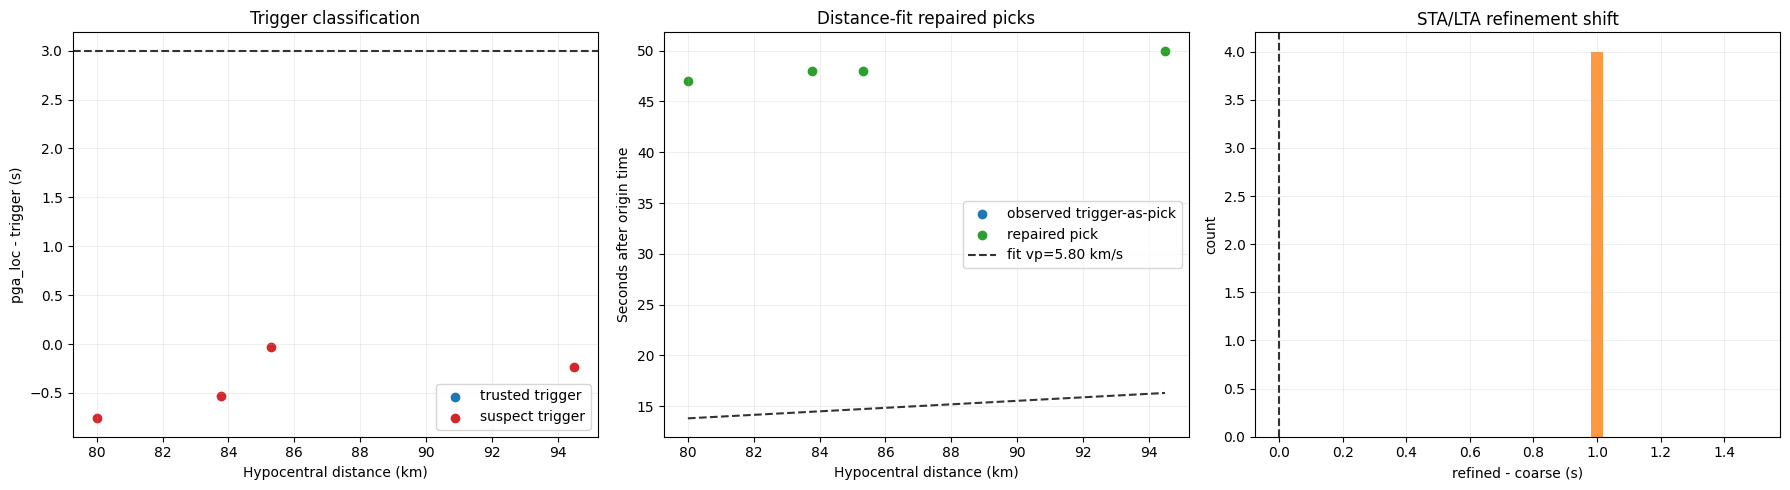

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trusted = refined_df["trigger_is_pick"].to_numpy(dtype=bool)
dist = refined_df["hypocentral_distance_km"].to_numpy(dtype=float)
delta = refined_df["trigger_to_pga_seconds"].to_numpy(dtype=float)
tp_obs = refined_df["p_pick_observed_seconds_after_origin"].to_numpy(dtype=float)
tp_rep = refined_df["p_pick_repaired_seconds_after_origin"].to_numpy(dtype=float)
tp_ref = tp_rep + (refined_df["stalta_refined_pick_aligned"].to_numpy(dtype=float) - refined_df["p_pick_repaired_aligned"].to_numpy(dtype=float)) / refined_df["sampling_rate_hz"].iloc[0]

axes[0].scatter(dist[trusted], delta[trusted], label="trusted trigger", color="C0")
axes[0].scatter(dist[~trusted], delta[~trusted], label="suspect trigger", color="C3")
axes[0].axhline(THRESHOLD_SECONDS, color="0.2", linestyle="--")
axes[0].set_xlabel("Hypocentral distance (km)")
axes[0].set_ylabel("pga_loc - trigger (s)")
axes[0].set_title("Trigger classification")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].scatter(dist[trusted], tp_obs[trusted], label="observed trigger-as-pick", color="C0")
axes[1].scatter(dist[~trusted], tp_rep[~trusted], label="repaired pick", color="C2")
x = np.linspace(dist.min(), dist.max(), 200)
y = fit_summary["intercept_s"] + fit_summary["slope_s_per_km"] * x
axes[1].plot(x, y, color="0.2", linestyle="--", label=f"fit vp={fit_summary['velocity_km_s']:.2f} km/s")
axes[1].set_xlabel("Hypocentral distance (km)")
axes[1].set_ylabel("Seconds after origin time")
axes[1].set_title("Distance-fit repaired picks")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

shift = refined_df["stalta_refined_pick_aligned"].to_numpy(dtype=float) - refined_df["p_pick_repaired_aligned"].to_numpy(dtype=float)
axes[2].hist(shift / refined_df["sampling_rate_hz"].iloc[0], bins=25, color="C1", alpha=0.8)
axes[2].axvline(0.0, color="0.2", linestyle="--")
axes[2].set_xlabel("refined - coarse (s)")
axes[2].set_ylabel("count")
axes[2].set_title("STA/LTA refinement shift")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


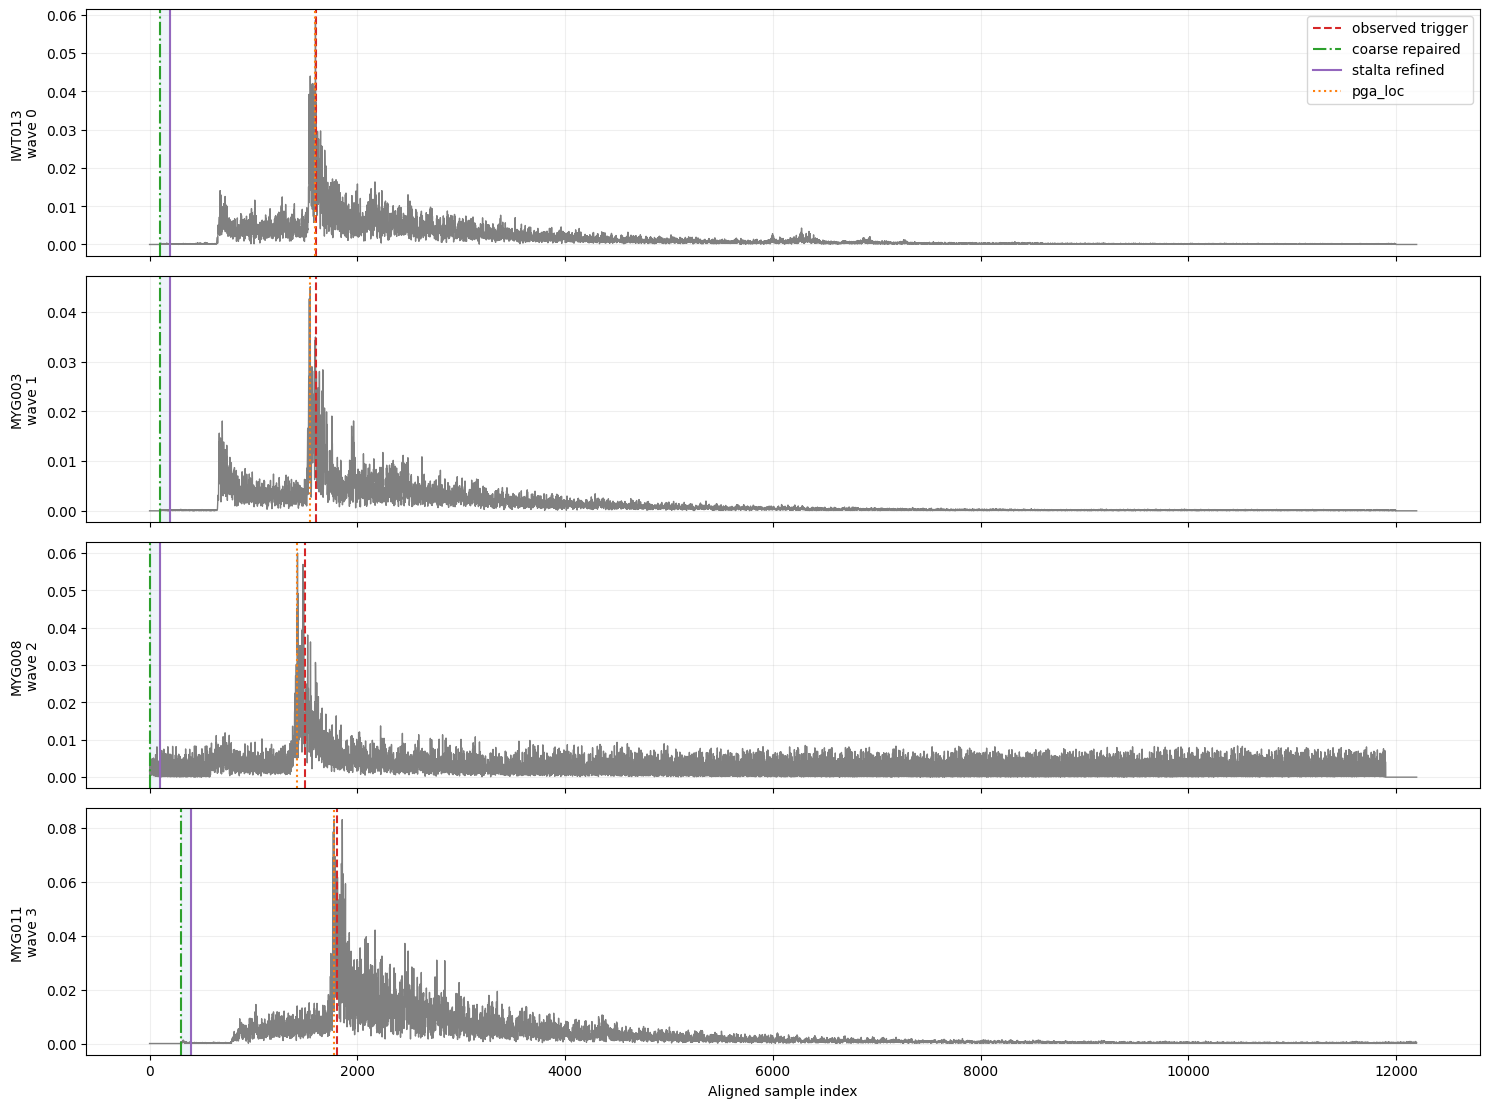

In [7]:
# 查看若干台站在对齐波形中的 observed/coarse/refined/pga_loc
VIEW_WAVE_IDXS = refined_df["wave_idx"].head(8).tolist()
with h5py.File(HDF5_PATH, "r") as f:
    grp = f["data"][str(EVENT_ID)]
    waveforms = grp["waveforms"][()]

fig, axes = plt.subplots(len(VIEW_WAVE_IDXS), 1, figsize=(15, 2.8 * len(VIEW_WAVE_IDXS)), sharex=True)
if len(VIEW_WAVE_IDXS) == 1:
    axes = [axes]

for ax, wave_idx in zip(axes, VIEW_WAVE_IDXS):
    row = refined_df[refined_df["wave_idx"] == wave_idx].iloc[0]
    wf = waveforms[wave_idx]
    env = np.linalg.norm(wf, axis=1)
    ax.plot(env, color="0.5", linewidth=1.0)
    ax.axvspan(int(row["stalta_search_left_aligned"]), int(row["stalta_search_right_aligned"]), color="C0", alpha=0.08)
    ax.axvline(int(row["p_pick_observed_aligned"]), color="C3", linestyle="--", label="observed trigger")
    ax.axvline(int(row["p_pick_repaired_aligned"]), color="C2", linestyle="-.", label="coarse repaired")
    ax.axvline(int(row["stalta_refined_pick_aligned"]), color="C4", linestyle="-", label="stalta refined")
    ax.axvline(int(row["pga_norm_aligned_loc"]), color="C1", linestyle=":", label="pga_loc")
    ax.set_ylabel(f"{row['station_code']}\nwave {wave_idx}")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper right")
axes[-1].set_xlabel("Aligned sample index")
plt.tight_layout()
plt.show()


In [8]:
# 用这个表来决定后面要不要把 refined pick 回写进主转换流程
summary_cols = [
    "wave_idx",
    "station_code",
    "source_network",
    "sensor_class",
    "hypocentral_distance_km",
    "trigger_to_pga_seconds",
    "trigger_is_pick",
    "p_pick_observed_aligned",
    "p_pick_repaired_aligned",
    "stalta_refined_pick_aligned",
    "stalta_method",
    "stalta_ratio_peak",
]
display(refined_df[summary_cols].sort_values("wave_idx"))


,wave_idx,station_code,source_network,sensor_class,hypocentral_distance_km,trigger_to_pga_seconds,trigger_is_pick,p_pick_observed_aligned,p_pick_repaired_aligned,stalta_refined_pick_aligned,stalta_method,stalta_ratio_peak
0,0,IWT013,knt,single_surface,85.307993,-0.03,False,1600,100,200,stalta_argmax,0.089765
1,1,MYG003,knt,single_surface,83.770164,-0.53,False,1600,100,200,stalta_argmax,0.122887
2,2,MYG008,knt,single_surface,79.997857,-0.76,False,1500,0,100,stalta_argmax,0.159412
3,3,MYG011,knt,single_surface,94.498507,-0.23,False,1800,300,400,stalta_argmax,0.197013
